In [2]:
import pandas as pd

df_live = pd.read_csv(
    "../data/processed/rolex_live_market.csv"
)

df_live.head()

,source,brand,search_collection,detected_collection,title,price,currency,seller_country,reference,production_year,...,html_file,scraped_at,size,collection,description,rrp,complication,rrp_clean,premium_pct,dataset_source
0,Chrono24,Rolex,Datejust,Datejust,Rolex Datejust 36 Rolex Datejust 1603 – 1975 –...,4100.0,EUR,FR,1603,1975.0,...,datejust_page1.html,2026-05-20T16:16:02.181800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,chrono24_live
1,Chrono24,Rolex,Datejust,Datejust,Rolex Datejust 36 Rolex Datejust 16200 black d...,5500.0,EUR,FR,16200,NaN,...,datejust_page1.html,2026-05-20T16:16:02.181826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,chrono24_live
2,Chrono24,Rolex,Datejust,Datejust,Rolex Datejust 36 Full set jamais polie,6990.0,EUR,FR,NaN,NaN,...,datejust_page1.html,2026-05-20T16:16:02.181842,NaN,NaN,NaN,NaN,NaN,NaN,NaN,chrono24_live
3,Chrono24,Rolex,Datejust,Datejust,Rolex Datejust 36 Blue Dial – Vintage 1979 – F...,5000.0,EUR,FR,1979,1979.0,...,datejust_page1.html,2026-05-20T16:16:02.181862,NaN,NaN,NaN,NaN,NaN,NaN,NaN,chrono24_live
4,Chrono24,Rolex,Datejust,Datejust,Rolex 1601 | 36 mm | 1973 | Cadran SIGMA argen...,4990.0,EUR,FR,1601,1973.0,...,datejust_page1.html,2026-05-20T16:16:02.181878,NaN,NaN,NaN,NaN,NaN,NaN,NaN,chrono24_live


In [3]:
df_live[
    [
        "title",
        "price",
        "reference",
        "rrp_clean",
        "premium_pct"
    ]
].dropna().head(20)

,title,price,reference,rrp_clean,premium_pct
20,Rolex Datejust 41 Rolex Datejust 41 Ref 126300...,9900.0,126300,7380.0,34.146341
21,Rolex Datejust 41 Rolex Datejust 41 Ref 126300...,9900.0,126300,7560.0,30.952381
26,Rolex Datejust 31 Full set - 178274-0029 - cod...,9599.0,178274,7500.0,27.986667
27,Rolex Datejust 31 Full set - 178274-0029 - cod...,9599.0,178274,9420.0,1.900212
28,Rolex Datejust 31 Full set - 178274-0029 - cod...,9599.0,178274,10200.0,-5.892157
29,Rolex Datejust 31 Full set - 178274-0029 - cod...,9599.0,178274,7320.0,31.133880
30,Rolex Datejust 31 Full set - 178274-0029 - cod...,9599.0,178274,9240.0,3.885281
31,Rolex Datejust 31 Full set - 178274-0029 - cod...,9599.0,178274,11640.0,-17.534364
32,Rolex Datejust 31 Full set - 178274-0029 - cod...,9599.0,178274,11820.0,-18.790186
33,Rolex Datejust 31 Full set - 178274-0029 - cod...,9599.0,178274,10920.0,-12.097070


In [4]:
df_live["premium_pct"].describe()

count    299.000000
mean      26.420327
std       47.320770
min      -28.638498
25%       -2.159291
50%       20.142602
75%       41.092860
max      424.193548
Name: premium_pct, dtype: float64

In [5]:
df_live.groupby("detected_collection")["premium_pct"].mean()

detected_collection
Datejust            14.840969
Daytona             29.552936
GMT-Master II       86.822017
Oyster Perpetual    43.446659
Submariner          37.103698
Name: premium_pct, dtype: float64

In [6]:
df_premium = df_live.dropna(subset=["premium_pct"]).copy()

sports_collections = [
    "Submariner",
    "GMT-Master II",
    "Daytona"
]

df_premium["segment"] = df_premium["detected_collection"].apply(
    lambda x: "Sports" if x in sports_collections else "Classic"
)

df_premium.groupby("segment").agg(
    listing_count=("url", "count"),
    median_price=("price", "median"),
    median_premium_pct=("premium_pct", "median"),
    mean_premium_pct=("premium_pct", "mean")
).reset_index()

,segment,listing_count,median_price,median_premium_pct,mean_premium_pct
0,Classic,216,12500.0,14.906181,15.768005
1,Sports,83,17900.0,32.420091,54.142031


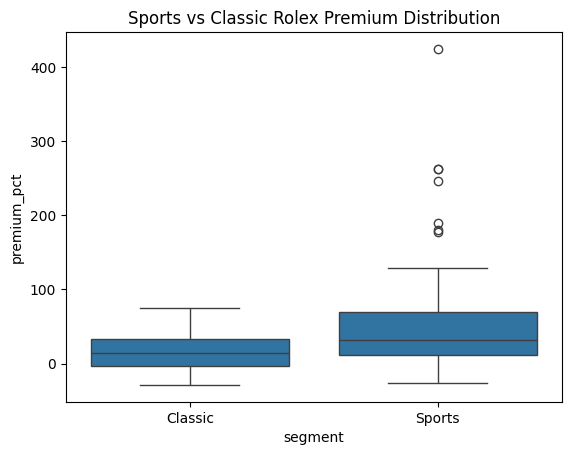

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df_premium,
    x="segment",
    y="premium_pct"
)

plt.title("Sports vs Classic Rolex Premium Distribution")
plt.show()

sports Rolex
整體 resale premium 明顯高於 classic models
--- market desirability concentration

In [8]:
df_premium.sort_values(
    "premium_pct",
    ascending=False
)[
    [
        "title",
        "detected_collection",
        "reference",
        "price",
        "rrp_clean",
        "premium_pct"
    ]
].head(20)

,title,detected_collection,reference,price,rrp_clean,premium_pct
676,Rolex GMT-Master II 126710BLRO by Sultanate of...,GMT-Master II,126710BLRO,48750.0,9300.0,424.193548
690,Rolex GMT-Master II Meteorite Coke Jubilee Sta...,GMT-Master II,116710LN,31750.0,8760.0,262.442922
746,Rolex GMT-Master II Meteorite Bruce Wayne Jubi...,GMT-Master II,116710LN,31750.0,8760.0,262.442922
748,Rolex NEW GMT-Master II 126710BLRO Pepsi Oyste...,GMT-Master II,126710BLRO,32205.0,9300.0,246.290323
801,Rolex GMT-Master II Rolex GMT-Master II “Pepsi...,GMT-Master II,126710BLRO,26900.0,9300.0,189.247312
526,Rolex Daytona “Panda” 116500LN 40mm Box Papers,Daytona,116500LN,35328.0,12600.0,180.380952
675,"Rolex GMT-Master II 126710BLRO ""Pepsi"" Boite +...",GMT-Master II,126710BLRO,25750.0,9300.0,176.881720
656,Rolex GMT-Master II Ref.126710BLRO Full Set 20...,GMT-Master II,126710BLRO,21299.0,9300.0,129.021505
730,Rolex GMT-Master II Ref: 126710BLRO 40mm Autom...,GMT-Master II,126710BLRO,20600.0,9300.0,121.505376
732,Rolex GMT-Master II Ref. 126710BLRO Pepsi Beze...,GMT-Master II,126710BLRO,20600.0,9300.0,121.505376


premium concentration
around highly liquid sports-oriented Rolex references

The highest resale premiums are overwhelmingly concentrated among Rolex sports references, particularly GMT-Master II and Daytona models.

These references display premium distributions and outlier behavior more commonly associated with speculative collectible markets than traditional luxury consumption goods.

In [10]:
#Collection-level premium ranking
collection_premium = (
    df_premium
    .groupby("detected_collection")
    .agg(
        listing_count=("url", "count"),
        median_premium=("premium_pct", "median"),
        mean_premium=("premium_pct", "mean")
    )
    .sort_values(
        "median_premium",
        ascending=False
    )
)

collection_premium

,listing_count,median_premium,mean_premium
detected_collection,,,
GMT-Master II,33,56.531532,86.822017
Oyster Perpetual,7,47.596899,43.446659
Submariner,20,36.247086,37.103698
Datejust,209,14.285714,14.840969
Daytona,30,10.538827,29.552936


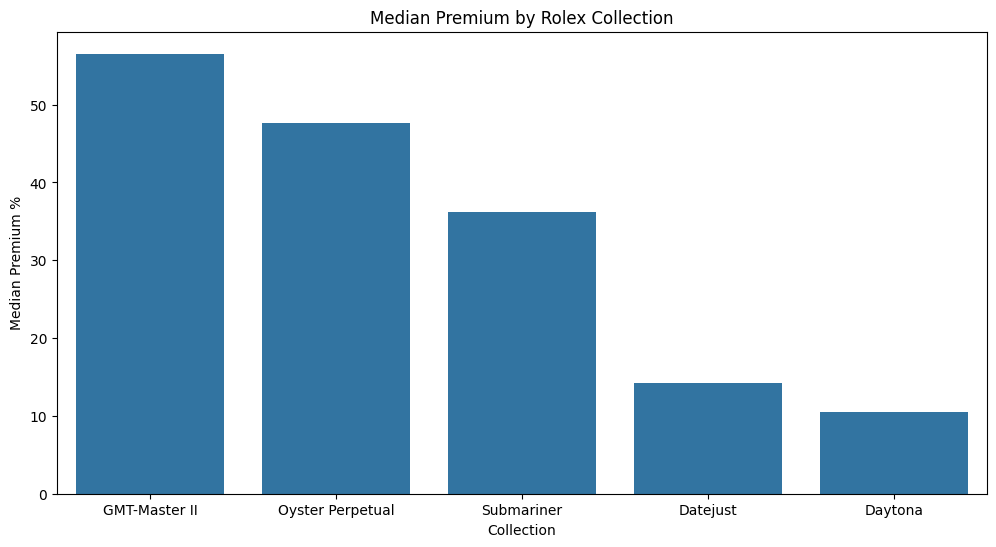

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize= (12,6))

plot_df = (
    collection_premium
    .reset_index()
)

sns.barplot(
    data=plot_df,
    x="detected_collection",
    y="median_premium"
)

plt.title("Median Premium by Rolex Collection")
plt.ylabel("Median Premium %")
plt.xlabel("Collection")

plt.show()

# Liquidity vs Premium

This section explores whether the most liquid Rolex collections
also generate the highest resale premiums.

In [14]:
liquidity_df = (
    df_premium
    .groupby("detected_collection")
    .agg(
        listing_count=("url", "count"),
        median_price=("price", "median"),
        median_premium=("premium_pct", "median"),
        mean_premium=("premium_pct", "mean")
    )
    .sort_values(
        "listing_count",
        ascending=False
    )
)

liquidity_df

,listing_count,median_price,median_premium,mean_premium
detected_collection,,,,
Datejust,209,12500.0,14.285714,14.840969
GMT-Master II,33,15940.0,56.531532,86.822017
Daytona,30,34900.0,10.538827,29.552936
Submariner,20,11015.0,36.247086,37.103698
Oyster Perpetual,7,7616.0,47.596899,43.446659


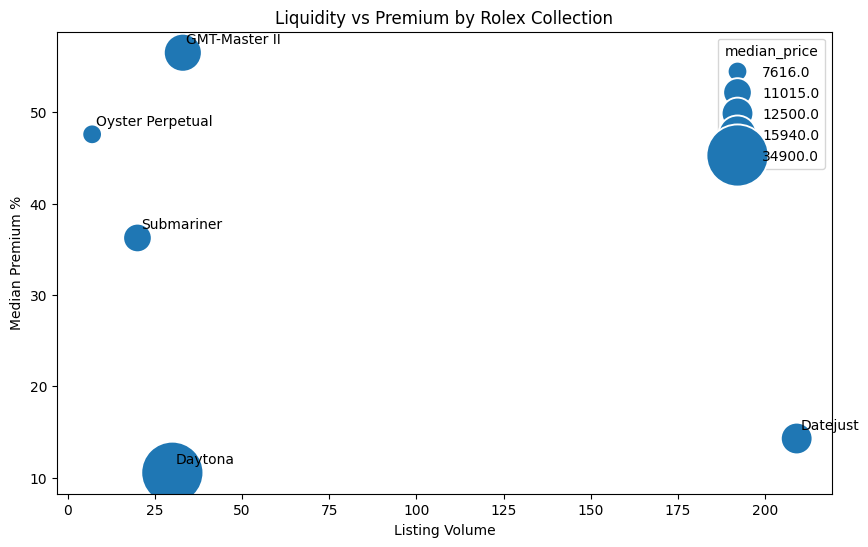

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=liquidity_df.reset_index(),
    x="listing_count",
    y="median_premium",
    size="median_price",
    sizes=(200, 2000)
)

for _, row in liquidity_df.reset_index().iterrows():
    plt.text(
        row["listing_count"] + 1,
        row["median_premium"] + 1,
        row["detected_collection"]
    )

plt.title("Liquidity vs Premium by Rolex Collection")
plt.xlabel("Listing Volume")
plt.ylabel("Median Premium %")

plt.show()

# Premium Volatility

This section analyzes premium dispersion across Rolex collections
to identify potential speculative market behavior.

In [16]:
volatility_df = (
    df_premium
    .groupby("detected_collection")
    .agg(
        listing_count=("url", "count"),
        median_premium=("premium_pct", "median"),
        premium_std=("premium_pct", "std"),
        premium_max=("premium_pct", "max")
    )
    .sort_values(
        "premium_std",
        ascending=False
    )
)

volatility_df

,listing_count,median_premium,premium_std,premium_max
detected_collection,,,,
GMT-Master II,33,56.531532,96.360692,424.193548
Daytona,30,10.538827,51.545455,180.380952
Submariner,20,36.247086,27.086595,104.194260
Datejust,209,14.285714,24.375508,74.796748
Oyster Perpetual,7,47.596899,20.667708,72.111111


# Modern vs Vintage Dynamics

This section compares resale premiums between modern and older Rolex references.

In [17]:
def classify_era(year):

    if pd.isna(year):
        return "Unknown"

    if year < 2000:
        return "Pre-2000"

    if year < 2015:
        return "2000-2014"

    return "Post-2015"


df_premium["era"] = df_premium["production_year"].apply(classify_era)

In [18]:
era_df = (
    df_premium
    .groupby("era")
    .agg(
        listing_count=("url", "count"),
        median_premium=("premium_pct", "median"),
        mean_premium=("premium_pct", "mean")
    )
)

era_df

,listing_count,median_premium,mean_premium
era,,,
2000-2014,35,-1.298701,4.527434
Post-2015,106,27.959799,33.794653
Unknown,158,15.017706,26.322686


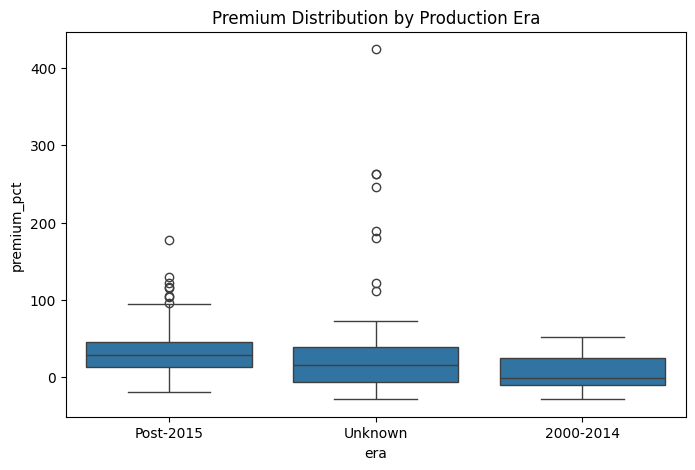

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_premium,
    x="era",
    y="premium_pct"
)

plt.title("Premium Distribution by Production Era")

plt.show()

# Reference Concentration

This section identifies which Rolex references dominate premium concentration.

In [20]:
reference_df = (
    df_premium
    .groupby("reference")
    .agg(
        listing_count=("url", "count"),
        median_premium=("premium_pct", "median"),
        mean_premium=("premium_pct", "mean")
    )
    .query("listing_count >= 3")
    .sort_values(
        "median_premium",
        ascending=False
    )
)

reference_df.head(20)

,listing_count,median_premium,mean_premium
reference,,,
126710BLRO,7,176.881720,201.235023
116500LN,6,113.055556,117.603175
126710BLNR,5,72.043011,76.329032
116710BLNR,3,56.531532,56.869369
116000,4,49.864341,49.670543
178341,12,46.980994,45.302814
114060,7,45.370370,43.915344
116519LN,6,38.336746,39.807877
278243,8,37.966296,37.759419


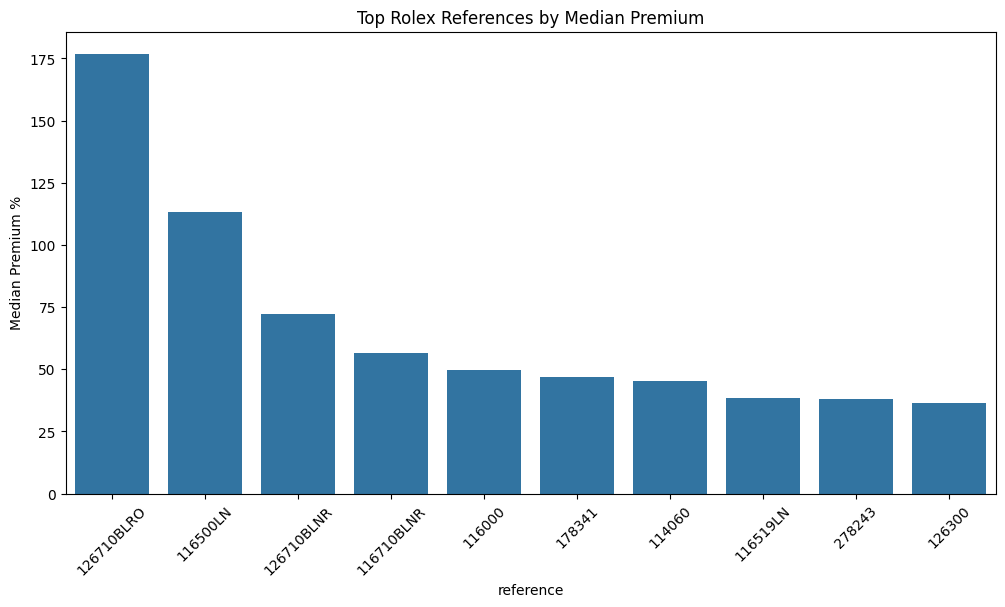

In [21]:
top_refs = reference_df.head(10).reset_index()

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_refs,
    x="reference",
    y="median_premium"
)

plt.title("Top Rolex References by Median Premium")
plt.ylabel("Median Premium %")

plt.xticks(rotation=45)

plt.show()

「live market snapshots continue to show
premium concentration around highly liquid
sports-oriented Rolex references」